# Linear regression and gradient descent

In [1]:
from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from utils import get_null_info, plot_features_against_target, target_info, plot_cross_validation_performance
#from sklearn.metrics import r2_score

In [2]:
RANDOM_SEED = 42
TARGET_NAME = 'price'

In [3]:
df = pd.read_csv("Housing.csv", usecols=['area', 'bedrooms', 'bathrooms', 'price']) # it's sorted by price!
df

,price,area,bedrooms,bathrooms
0,13300000,7420,4,2
1,12250000,8960,4,4
2,12250000,9960,3,2
3,12215000,7500,4,2
4,11410000,7420,4,1
...,...,...,...,...
540,1820000,3000,2,1
541,1767150,2400,3,1
542,1750000,3620,2,1
543,1750000,2910,3,1


In [13]:
duplicates_df = df[df.duplicated()]
display(duplicates_df)

,price,area,bedrooms,bathrooms
50,7420000,7440,3,2
104,6195000,5500,3,2
280,4270000,6360,2,1
367,3675000,3630,2,1


In [14]:
df = df.drop(index=duplicates_df.index)
df.head()

,price,area,bedrooms,bathrooms
0,13300000,7420,4,2
1,12250000,8960,4,4
2,12250000,9960,3,2
3,12215000,7500,4,2
4,11410000,7420,4,1


In [15]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=[TARGET_NAME]), df[TARGET_NAME], test_size=0.2, shuffle=True, random_state=RANDOM_SEED)
df_train = pd.concat((X_train, y_train), axis=1)
df_test = pd.concat((X_test, y_test), axis=1)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (432, 3)
Test shape: (109, 3)


In [16]:
df_train.describe()

,area,bedrooms,bathrooms,price
count,432.00000,432.000000,432.000000,4.320000e+02
mean,5058.00000,2.953704,1.275463,4.680771e+06
std,2112.79853,0.760196,0.496437,1.774669e+06
min,1650.00000,1.000000,1.000000,1.750000e+06
25%,3520.00000,2.000000,1.000000,3.430000e+06
50%,4500.00000,3.000000,1.000000,4.270000e+06
75%,6360.00000,3.000000,2.000000,5.600000e+06
max,16200.00000,6.000000,4.000000,1.225000e+07


In [17]:
df_train.dtypes

area         int64
bedrooms     int64
bathrooms    int64
price        int64
dtype: object

In [18]:
df_nulls = get_null_info(df_train)
df_nulls

No missing values are found in the dataframe


[]

In [19]:
df_nulls = get_null_info(df_test)
df_nulls

No missing values are found in the dataframe


[]

Unique target values:


,counts,%
price,,
4200000,15,0.03
3500000,12,0.03
4900000,10,0.02
3290000,8,0.02
3360000,7,0.02
...,...,...
6790000,1,0.00
8043000,1,0.00
3332000,1,0.00


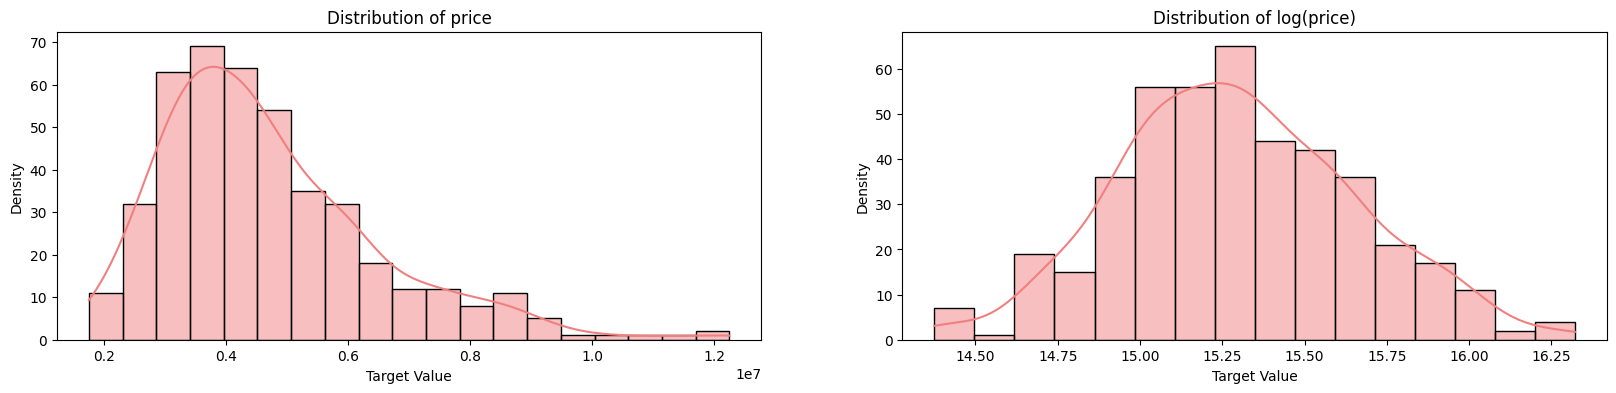

In [24]:
target_info(df_train, "price", "log")

target is normal, right skewed, should be transformed

In [22]:
y_train_log = np.log(y_train)

Generating diagnostic profiling for: area


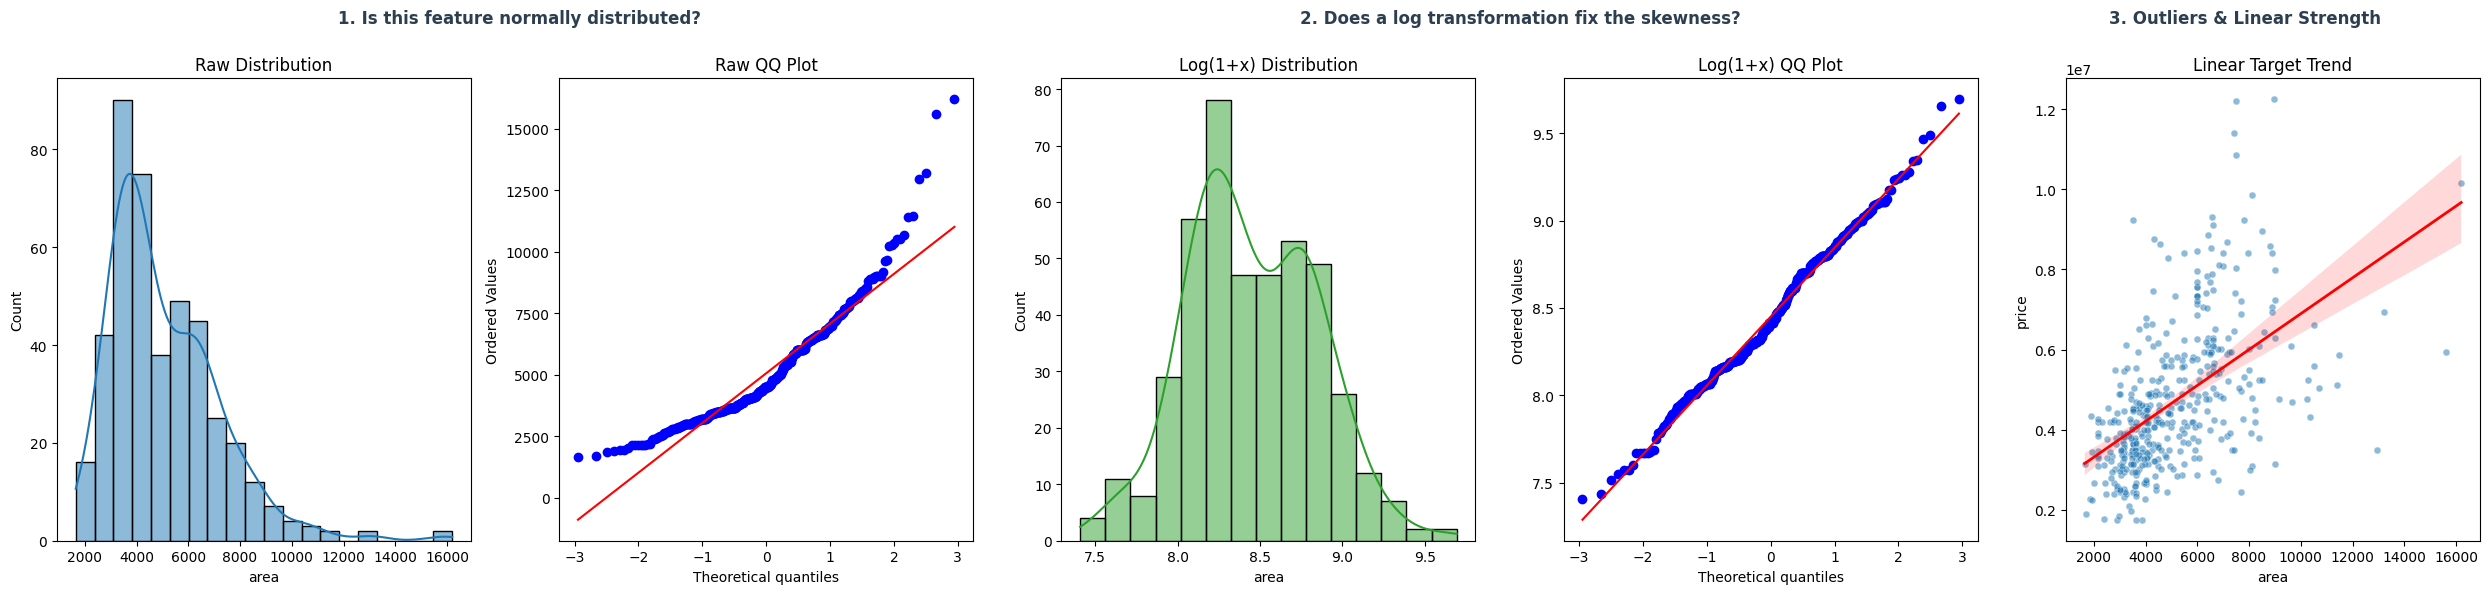

In [23]:
plot_features_against_target(df_train, ['area'], TARGET_NAME, None)

- area (continuous) - normal; right-skewed, log transformation helps, doesn't look too linear
- bedrooms - discrete; shouldn't be transformed
- bathrooms - discrete; shouldn't be transformed

In [ ]:
# create and fit the scaler on numerical data
scaler = StandardScaler().fit(X_train)

# saving the scaler instance for decoding later
scaler_df = pd.DataFrame({'col': X.columns, 'std': scaler.scale_})

# transform the data
X_scaled = pd.DataFrame(scaler.transform(X), columns=X.columns)

**Standard linear regression** looks like this:
$$y = kx + b$$
**In more advanced quadratic forms** $y = kx^2+bx+c$ etc.

---

**In Data Science**, the more common convention is:
$$h(x) = w_0 + w_1x, \space where$$
- $w_1$ - trainable weight of a feature
- $w_0$ - trainable *bias*
- $x$ - an input feature

**In more complex forms in Data Science** (for $n$ trainable parameters):
$$h(x) = w_0 + \sum_{i=1}^n{w_ix_i}, \space where$$
- $n$ is the number of features
- $w_1, ... w_n$ - a vector of $n$ trainable weights
- $x_1, ... x_n$ - a matrix of input features
- $w_0$ - trainable *bias*

**In complex matrix form in Data Science** (for multidimensional spaces and computation efficiency):
$$h(x) = Xw, \space where$$
- $X$ - input features' matrix with an additional dummy features of $1$s in order to properly multiply the matrices
- $w$ - trainable weights vector

The matrix multiplication itself still preserves the sum of the products mechanism:

- $Xw = \begin{bmatrix} 1 & x_{1,1} & x_{1,2} & \dots & x_{1,n} \\ 1 & x_{2,1} & x_{2,2} & \dots & x_{2,n} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_{m,1} & x_{m,2} & \dots & x_{m,n} \end{bmatrix} \begin{bmatrix} w_0 \\ w_1 \\ w_2 \\ \vdots \\ w_n \end{bmatrix} = \begin{bmatrix} (1 \cdot w_0) + (x_{1,1} \cdot w_1) + (x_{1,2} \cdot w_2) + \dots + (x_{1,n} \cdot w_n) \\ (1 \cdot w_0) + (x_{2,1} \cdot w_1) + (x_{2,2} \cdot w_2) + \dots + (x_{2,n} \cdot w_n) \\ \vdots \\ (1 \cdot w_0) + (x_{m,1} \cdot w_1) + (x_{m,2} \cdot w_2) + \dots + (x_{m,n} \cdot w_n) \end{bmatrix}=\begin{bmatrix} pred_0 \\ pred_1 \\ \dots \\ pred_m \end{bmatrix},\space where$ 
- $n$ is the number of features
- $m$ - number of samples. 
- One element $x_{mn}$ means "an $m$-th value of feature $n$.
- The col of $1$s added to properly multiply features because of the *bias* present

---

In [13]:
def add_np_ones_col(matrix: np.ndarray):
    np_ones = np.ones((matrix.shape[0], 1))
    return np.concatenate((np_ones, matrix), axis=1)

# напишіть функцію гіпотези лінійної регресії у векторному вигляді
def linear_forward_pass(features_matrix: np.ndarray, weights_col: np.ndarray):
    return features_matrix @ weights_col

# створіть функцію для обчислення функції втрат у векторному вигляді
def mse_loss(predictions: np.ndarray, ground_truth: np.ndarray):
    return (1/2) * np.sum((predictions - ground_truth)**2)/len(predictions)

def r2_score_custom(predictions: np.ndarray, ground_truth: np.ndarray):
    # 1. Total variation: how much the actual data spreads around its own mean
    var_mean = np.sum((ground_truth - np.mean(ground_truth)) ** 2)

    # 2. Residual variation: how much the actual data spreads around the regression line
    var_line = np.sum((ground_truth - predictions) ** 2)

    # if we only have 1 or less samples, R2 doesn't make sense
    if len(predictions) <= 1:
        return 0.0
    return 1 - (var_line / var_mean)

$$J(w) = \frac{1}{2n} * \sum_{i=1}^n{(\hat y_i-y_i)^2} \space (MSE), \space where$$
- $\frac{1}{2}$ is a coefficient to cancel out the future derivative's factor of 2. Given deep networks, by cancelling out $\frac{1}{2} \cdot \frac{2}{1}$, we eliminate billions of additional multiplications + omit dealing with numbers twice as huge, which helps the optimization problem of minimization. Without it, we would also have to cut our learning rate in half, and it would still be less efficient anyway.
- $n$: number of samples, $\frac{1}{n}$ makes it "error per point"
- $\hat y_i$: $i$-th prediction, **or in other words**: $\hat y_i = w_0 + \sum_{i=1}^n{w_i x_i}$ (forward pass)
- $y_i$: $i$-th ground truth

Now, in order to find the rate of change of our <u>loss</u> with respect to <u>weights</u> using chain rule, we need to find the partial derivative:

$$J(w) = \frac{\partial J(w)}{\partial w}=\frac{\partial [\frac{1}{2n}\sum_{i=1}^n{(\hat y_i-y_i)^2}]}{\partial w}$$

Substitute $\hat y_i$ for the forward pass where the variable $w$ is explicitly present in order to differentiate with respect to it:

$$\begin{gather}
J(w)=\frac{\partial [\frac{1}{2n}\sum_{i=1}^n{\left[(w_ix_i+w_0)-y_i\right]^2}]}{\partial w}=\frac{1}{2n}\sum_{i=1}^n{\underbrace{2(w_ix_i+w_0-y_i)}_{\text{outer derivative}} \cdot \underbrace{\frac{\partial(w_ix_i+w_0-y_i)}{\partial w_i}}_{\text{inner derivative (chain rule)}}}=
\\
=\frac{2}{2n}\sum_{i=1}^n{(w_ix_i+w_0-y_i)(x_i+0-0)}=\frac{1}{n}\sum_{i=1}^n{x_i(w_ix_i+w_0-y_i)}
\end{gather}$$

Substitute back:
$$\nabla J(w) = \frac{1}{n}\sum_{i=1}^n{x_i(\hat y_i-y_i)}$$

In order to vectorize it, we need to transpose to align the $i$-th error with the $i$-th feature across all samples (in order for the shapes to allow multiplication):
$$\nabla J(w) = \frac{1}{n}X^T(\hat y-y)$$

In [14]:
def mse_loss_der(features: np.ndarray, predictions: np.ndarray, ground_truth: np.ndarray):
    n = len(predictions)
    return (1/n) * features @ (predictions - ground_truth)

# реалізуйте один крок градієнтного спуску
def grad(lr: float, loss_der: Callable, features: np.ndarray, predictions: np.ndarray, ground_truth: np.ndarray):
    return lr * loss_der(features, predictions, ground_truth)

In [15]:
# n_fold determines the equal parts to split the dataset into
# 1 part will be used for validation and n_fold-1 parts for training
def cross_validation(n_folds: int, features: np.ndarray, target: np.ndarray):
    len_features = len(features)

    if len_features % n_folds != 0:
        err = f"Can't divide {len_features} by {n_folds} evenly. Please, change 'n_folds' or trim the data"
        raise ValueError(err)

    samples_per_fold = len_features // n_folds
    for i in range(n_folds):
        val_start_idx = i*samples_per_fold
        val_end_idx = i*samples_per_fold+samples_per_fold

        val_target = target[val_start_idx:val_end_idx]
        val_features = features[val_start_idx:val_end_idx]

        train_target = np.concatenate((target[:val_start_idx], target[val_end_idx:]), axis=0)
        train_features = np.concatenate((features[:val_start_idx], features[val_end_idx:]), axis=0)

        yield train_features, val_features, train_target, val_target

In [46]:
def train_and_validate_fold(lr: float, epochs: int, x_train: np.ndarray, y_train: np.ndarray, x_val: np.ndarray, y_val: np.ndarray, w_init: np.ndarray):
    train_mses, train_r2s = [], []
    val_mses, val_r2s = [], []

    w = w_init.copy()

    for epoch in range(epochs):
        # 1. Forward pass & weight update on Train Data
        y_hat_train = linear_forward_pass(x_train, w)
        gradients = grad(lr, mse_loss_der, x_train.T, y_hat_train, y_train)
        w = w - gradients

        # 2. Record Train Metrics at this exact epoch step
        t_mse = mse_loss(y_hat_train, y_train)
        train_mses.append(t_mse)
        train_r2s.append(r2_score_custom(y_hat_train, y_train))

        # 3. Record Validation Metrics at this exact epoch step (using current w)
        y_hat_val = linear_forward_pass(x_val, w)
        v_mse = mse_loss(y_hat_val, y_val)
        val_mses.append(v_mse)
        val_r2s.append(r2_score_custom(y_hat_val, y_val))

    # 3. Print the final epoch's performance to see how the model finished
    print(f"(train final epoch) MSE = {train_mses[-1]}")
    print(f"(train final epoch) RMSE = {np.sqrt(train_mses[-1])}")
    print(f"(train final epoch) R2 = {train_r2s[-1]}")
    print()
    print(f"(validation final epoch) MSE = {val_mses[-1]}")
    print(f"(validation final epoch) RMSE = {np.sqrt(val_mses[-1])}")
    print(f"(validation final epoch) R2 = {val_r2s[-1]}")
    print()

    return w, np.array(train_mses), np.array(train_r2s), np.array(val_mses), np.array(val_r2s)

In [17]:
X_scaled

,area,bedrooms,bathrooms
0,1.046726,1.398035,1.425881
1,1.755665,1.398035,5.412453
2,2.216015,0.042592,1.425881
3,1.083554,1.398035,1.425881
4,1.046726,1.398035,-0.567405
...,...,...,...
536,-0.988021,-1.312850,-0.567405
537,-1.264231,0.042592,-0.567405
538,-0.702604,-1.312850,-0.567405
539,-1.029452,0.042592,-0.567405


In [ ]:
# --- constants ---
INITIAL_WEIGHT_LOWER_BND = 1e-6
INITIAL_WEIGHT_UPPER_BND = 1e-5

rng = np.random.default_rng(seed=RANDOM_SEED)
X_scaled = X_scaled[:-1]
log_y = log_y[:-1]
y_numpy = log_y.to_numpy().reshape(-1, 1)
w_init = rng.uniform(low=INITIAL_WEIGHT_LOWER_BND, high=INITIAL_WEIGHT_UPPER_BND, size=(X_scaled.shape[1]+1, 1))
X_modified = add_np_ones_col(X_scaled)

In [35]:
log_y

0      16.403275
1      16.321036
2      16.321036
3      16.318175
4      16.250001
         ...    
539    14.433395
540    14.414347
541    14.384879
542    14.375126
543    14.375126
Name: price, Length: 540, dtype: float64

In [61]:
LR = 0.2
N_FOLDS = 10
EPOCHS = 20

# Initialize structures to hold history profiles for each fold
fold_train_mses, fold_train_r2s = [], []
fold_val_mses, fold_val_r2s = [], []

# --- Cross-Validation Execution ---
for i, (train_features, val_features, train_target, val_target) in enumerate(cross_validation(n_folds=N_FOLDS, features=X_modified, target=y_numpy)):
    print(f"Processing Fold {i+1}/{N_FOLDS}...")

    # do not update weights during cross-validation
    _, t_mse, t_r2, v_mse, v_r2 = train_and_validate_fold(LR, EPOCHS, train_features, train_target, val_features, val_target, w_init)

    fold_train_mses.append(t_mse)
    fold_train_r2s.append(t_r2)
    fold_val_mses.append(v_mse)
    fold_val_r2s.append(v_r2)

print("----- Cross-Validation Finished -----")

# --- Mathematical Matrix Averaging Across Folds ---
# Converts lists of 5 arrays into 2D matrices of shape (5, 1000), then takes mean along vertical axis
avg_train_loss = np.mean(np.array(fold_train_mses), axis=0)
avg_val_loss = np.mean(np.array(fold_val_mses), axis=0)
avg_train_r2 = np.mean(np.array(fold_train_r2s), axis=0)
avg_val_r2 = np.mean(np.array(fold_val_r2s), axis=0)

Processing Fold 1/10...
(train final epoch) MSE = 0.08396010044125225
(train final epoch) RMSE = 0.2897586934696736
(train final epoch) R2 = -0.7902421280981986

(validation final epoch) MSE = 0.4828357909760901
(validation final epoch) RMSE = 0.6948638650671728
(validation final epoch) R2 = -45.59086527811274

Processing Fold 2/10...
(train final epoch) MSE = 0.06696121769975871
(train final epoch) RMSE = 0.258768656718233
(train final epoch) R2 = -0.008575907522910597

(validation final epoch) MSE = 0.11976276221882115
(validation final epoch) RMSE = 0.3460675688631068
(validation final epoch) R2 = -88.9023135368338

Processing Fold 3/10...
(train final epoch) MSE = 0.06740458742389575
(train final epoch) RMSE = 0.2596239346129238
(train final epoch) R2 = 0.06465909789752222

(validation final epoch) MSE = 0.08101075726634646
(validation final epoch) RMSE = 0.2846238873783198
(validation final epoch) R2 = -132.47435131898763

Processing Fold 4/10...
(train final epoch) MSE = 0.063524

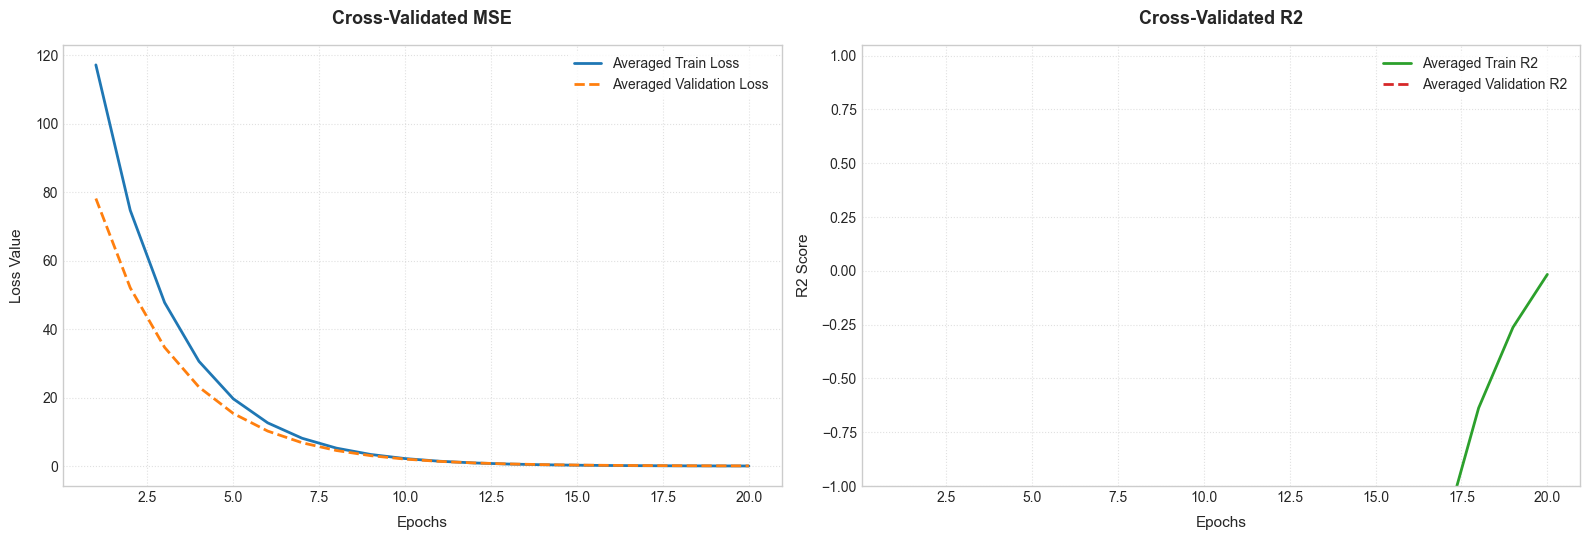

In [62]:
# Run the stylized output
plot_cross_validation_performance(avg_train_loss, avg_val_loss, avg_train_r2, avg_val_r2)

In [ ]:
# def train(lr: float, epochs: int, x_train: np.ndarray, y_train: np.ndarray, w_init: np.ndarray):
#     # 1. Initialize flat lists to store metrics for EVERY epoch
#     train_mses, train_rmses, train_r2s = [], [], []

#     w = w_init.copy()

#     for epoch in range(epochs):
#         y_hat = linear_forward_pass(x_train, w)

#         # Calculate gradients and update weights
#         gradients = grad(lr, mse_loss_der, x_train.T, y_hat, y_train)
#         w = w - gradients

#         # Calculate metrics for the current epoch step
#         train_mse = mse_loss(y_hat, y_train)
#         train_rmse = np.sqrt(train_mse)
#         train_r2 = r2_score_custom(y_hat, y_train)

#         # 2. Append metrics sequentially to the lists
#         train_mses.append(train_mse)
#         train_rmses.append(train_rmse)
#         train_r2s.append(train_r2)

#     # 3. Print the final epoch's performance to see how the model finished
#     print(f"(train final epoch) MSE = {train_mses[-1]}")
#     print(f"(train final epoch) RMSE = {train_rmses[-1]}")
#     print(f"(train final epoch) R2 = {train_r2s[-1]}")
#     print()

#     # 4. Return the full history arrays so you can average them across folds later
#     return w, np.array(train_mses), np.array(train_rmses), np.array(train_r2s)

# def validate(x_valid, y_valid, w_trained):
#     y_hat = linear_forward_pass(x_valid, w_trained)
#     valid_mse = mse_loss(y_hat, y_valid)
#     valid_rmse = np.sqrt(valid_mse)
#     valid_r2 = r2_score_custom(y_hat, y_valid)
#     print(f"(validation) MSE = {valid_mse}")
#     print(f"(validation) RMSE = {valid_rmse}")
#     print(f"(validation) R2 = {valid_r2}")
#     print()

#     return valid_mse, valid_rmse, valid_r2

In [ ]:
# constants
RANDOM_SEED = 42
LR = 1e-3
N_FOLDS = 5
EPOCHS = 1000

# init weights
w_init = rng.uniform(low=1e-6, high=1e-5, size=(4, 1))
X_modified = add_np_ones_col(X) # to account for w_0 (bias)

# means per fold
mean_mses_train, mean_rmses_train, mean_r2s_train = [], [], []
mses_valid, rmses_valid, r2s_valid = [], [], []

for i, (train_features, val_features, train_target, val_target) in enumerate(cross_validation(n_folds=N_FOLDS, features=X_modified, target=y)):
    print(f"Fold {i+1}")
    w_fold = w_init.copy()
    # do not update weights during cross-validation
    w_trained, train_mses, train_rmses, train_r2s = train(LR, EPOCHS, train_features, train_target, w_fold)

    # average metrics PER FOLD (train)
    mean_mses_train = np.append(mean_mses_train, np.mean(train_mses))
    mean_rmses_train = np.append(mean_rmses_train, np.mean(train_rmses))
    mean_r2s_train = np.append(mean_r2s_train, np.mean(train_r2s))

    valid_mse, valid_rmse, valid_r2 = validate(val_features, val_target, w_trained)
    # metrics PER FOLD (validation)
    mses_valid = np.append(mses_valid, valid_mse)
    rmses_valid = np.append(rmses_valid, valid_rmse)
    r2s_valid = np.append(r2s_valid, valid_r2)


print("----- Finished -----")

Fold 1
(train final epoch) MSE = 0.7997321515739061
(train final epoch) RMSE = 0.8942774466427665
(train final epoch) R2 = 0.9874867105126706

(validation) MSE = 1.7802326881951664
(validation) RMSE = 1.334253607150892
(validation) R2 = 0.9724229783098566

Fold 2
(train final epoch) MSE = 0.5826410998421218
(train final epoch) RMSE = 0.7633093081065642
(train final epoch) R2 = 0.9916149200247804

(validation) MSE = 4.954521104929806
(validation) RMSE = 2.2258753570067227
(validation) R2 = 0.9025020425077793

Fold 3
(train final epoch) MSE = 0.8950805674492036
(train final epoch) RMSE = 0.9460869766830128
(train final epoch) R2 = 0.9861188791886376

(validation) MSE = 1.1975633120777684
(validation) RMSE = 1.094332359056319
(validation) R2 = 0.9804025664892628

Fold 4
(train final epoch) MSE = 0.9976241361775172
(train final epoch) RMSE = 0.9988113616582048
(train final epoch) R2 = 0.9840587924887075

(validation) MSE = 0.711195901858167
(validation) RMSE = 0.843324315941481
(validation

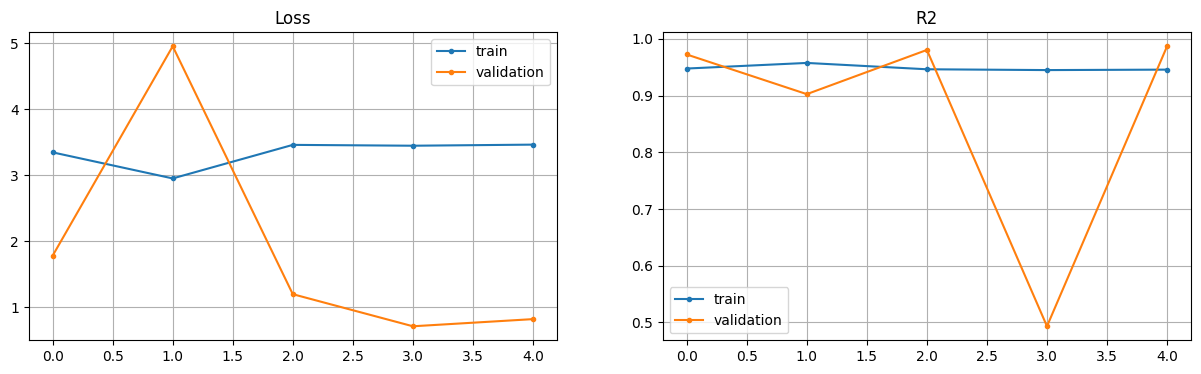

In [ ]:
def plot_loss_acc_per_ep(train_losses, valid_losses, train_r2, valid_r2s):
    _, axes = plt.subplots(ncols=2, figsize=(15, 4))

    axes[0].plot(np.arange(len(train_losses)), train_losses, ".-")
    axes[0].plot(np.arange(len(valid_losses)), valid_losses, ".-")
    axes[0].legend(["train", "validation"])
    axes[0].set_title("Loss")
    axes[0].grid()

    axes[1].plot(np.arange(len(train_r2)), train_r2, ".-")
    axes[1].plot(np.arange(len(valid_r2s)), valid_r2s, ".-")
    axes[1].legend(["train", "validation"])
    axes[1].set_title("R2")
    axes[1].grid()

plot_loss_acc_per_ep(mean_mses_train, mses_valid, mean_r2s_train, r2s_valid)

## Analytical solution